## Name- Kirti Singh (25P02F1003)

## Name- Pranjal Tamrakar (25P02F1006)

# MELD Multimodal Emotion & Sarcasm Detection

## Project Overview
This notebook builds a **multimodal sarcasm detection system** using the MELD (Multimodal EmotionLines Dataset).
It combines:
- **Text-based emotion prediction** via fine-tuned BERT
- **Audio-based emotion prediction** via a CNN on Mel spectrograms
- **Sarcasm detection** by comparing text vs. audio emotional signals

## Dataset
- **MELD** (Multimodal EmotionLines Dataset): TV show dialogues annotated with 7 emotions.
- Emotion classes: `anger`, `disgust`, `fear`, `joy`, `neutral`, `sadness`, `surprise`
- Source: https://affective-meld.github.io

---
# PART 1 — ENVIRONMENT SETUP
---

## 1.1 Kaggle Default Environment Check
Kaggle notebooks come pre-loaded with common data science libraries.
This cell verifies the environment and lists all available input files.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kirti1210/text-model/config.json
/kaggle/input/datasets/kirti1210/text-model/tokenizer_config.json
/kaggle/input/datasets/kirti1210/text-model/model.safetensors
/kaggle/input/datasets/kirti1210/text-model/special_tokens_map.json
/kaggle/input/datasets/kirti1210/text-model/vocab.txt
/kaggle/input/datasets/kirti1210/audio-testing/sarcasm_5.aac
/kaggle/input/datasets/kirti1210/audio-testing/sarcasm_4.aac
/kaggle/input/datasets/kirti1210/audio-testing/sarcasm_2.aac
/kaggle/input/datasets/kirti1210/audio-testing/sarcasm_3.aac
/kaggle/input/datasets/kirti1210/audio-testing/sarcasm_6.aac
/kaggle/input/datasets/kirti1210/audio-testing/sarcasm_1.aac
/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/test_sent_emo.csv
/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/README.txt
/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/._train_splits
/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/dev_sent_emo.csv
/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/test/._output_repeated_splits_test
/kaggle

## 1.2 Import Core Libraries

In [2]:
import pandas as pd# DataFrame operations, CSV loading
import numpy as np# Array operations, numerical processing
import os # File system navigation, path operations
print("Libraries loaded ")


Libraries loaded 


## 1.3 Explore Available Files in Kaggle Input
Verify that the MELD dataset has been correctly mounted before loading.

In [3]:
base_path = "/kaggle/input"

for root, dirs, files in os.walk(base_path):
    print(root, "→", len(files), "files")


/kaggle/input → 0 files
/kaggle/input/meld-dataset → 0 files
/kaggle/input/meld-dataset/MELD-RAW → 0 files
/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw → 4 files
/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/test → 1 files
/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/test/output_repeated_splits_test → 4807 files
/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/train → 1 files
/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/train/train_splits → 9989 files
/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/dev → 0 files
/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/dev/dev_splits_complete → 1112 files
/kaggle/input/meld-dataset/MELD-Features-Models → 0 files
/kaggle/input/meld-dataset/MELD-Features-Models/MELD.Features.Models → 1 files
/kaggle/input/meld-dataset/MELD-Features-Models/MELD.Features.Models/features → 13 files
/kaggle/input/meld-dataset/MELD-Features-Models/MELD.Features.Models/models → 6 files
/kaggle/input/datasets → 0 files
/kaggle/input/datasets/kirti1210 → 0 files
/kaggle/input/datase

---
# PART 2 — TEXT MODEL: BERT FOR EMOTION CLASSIFICATION
---

We fine-tune a pre-trained **BERT** (Bidirectional Encoder Representations from Transformers)
model to classify dialogue utterances into 7 emotion categories.

**Why BERT?**
- Understands context bidirectionally (reads both left and right)
- Pre-trained on massive corpora — requires less labelled data to fine-tune
- State-of-the-art on text classification benchmarks

## 2.1 Load the MELD Training CSV

In [4]:
# List files inside the MELD raw dataset folder to verify the directory structure
# Expected files: train_sent_emo.csv, dev_sent_emo.csv, test_sent_emo.csv
base_path = "/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw"
print(os.listdir(base_path))


['test_sent_emo.csv', 'README.txt', '._train_splits', 'dev_sent_emo.csv', 'test', 'train', 'dev']


In [5]:
import os

# Recursively scan the dataset and print every CSV file path
# Ensures we find train / dev / test CSVs regardless of folder dept
base_path = "/kaggle/input/meld-dataset"

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))


/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/test_sent_emo.csv
/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/dev_sent_emo.csv
/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/train/train_sent_emo.csv


In [6]:
 #Load the training split into a pandas DataFrame
# Key columns used:
#   - 'Utterance'  : raw text of the spoken sentence
#   - 'Emotion'    : ground-truth emotion label (anger/joy/etc.)
#   - 'Dialogue_ID': groups utterances by conversation
#   - 'Utterance_ID': position of utterance within dialogue
train_path = "/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/train/train_sent_emo.csv"
train_df = pd.read_csv(train_path)

train_df.head()


,Sr No.,Utterance,Speaker,Emotion,Sentiment,Dialogue_ID,Utterance_ID,Season,Episode,StartTime,EndTime
0,1,also I was the point person on my companys tr...,Chandler,neutral,neutral,0,0,8,21,"00:16:16,059","00:16:21,731"
1,2,You mustve had your hands full.,The Interviewer,neutral,neutral,0,1,8,21,"00:16:21,940","00:16:23,442"
2,3,That I did. That I did.,Chandler,neutral,neutral,0,2,8,21,"00:16:23,442","00:16:26,389"
3,4,So lets talk a little bit about your duties.,The Interviewer,neutral,neutral,0,3,8,21,"00:16:26,820","00:16:29,572"
4,5,My duties? All right.,Chandler,surprise,positive,0,4,8,21,"00:16:34,452","00:16:40,917"


## 2.2 Install & Load the BERT Tokenizer

In [7]:
# Install the HuggingFace Transformers library
# Provides pre-trained BERT, tokenizers, and fine-tuning utilities
!pip install transformers


In [8]:
# Load the BERT tokenizer for 'bert-base-uncased'
# 'uncased' means all text is lowercased — suits informal dialogue
# The tokenizer converts raw text → token IDs that BERT understands
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
print("Tokenizer ready ✅")


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Tokenizer ready ✅


## 2.3 Tokenize Text Utterances

In [9]:
# Extract the 'Utterance' column as a plain Python list of strings
# astype(str) ensures no NaN values cause failures during tokenization
texts = train_df["Utterance"].astype(str).tolist()
print(texts[:5])# Sanity check — print first 5 utterances


['also I was the point person on my company\x92s transition from the KL-5 to GR-6 system.', 'You must\x92ve had your hands full.', 'That I did. That I did.', 'So let\x92s talk a little bit about your duties.', 'My duties?  All right.']


## 2.4 Encode Emotion Labels as Integers
BERT's classification head requires integer class indices, not strings.

In [10]:
# Tokenize all utterances in batch
# padding=True     → pad shorter sequences to match the longest in batch
# truncation=True  → cut sequences longer than max_length
# max_length=50    → dialogue utterances are short; 50 tokens is sufficient
# return_tensors="pt" → return PyTorch tensors (needed for BERT model input)
encodings = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=50,
    return_tensors="pt"
)

print("Input IDs shape:", encodings["input_ids"].shape)


Input IDs shape: torch.Size([9989, 50])


In [11]:
# Inspect all unique emotion labels present in the training set
# Expected: ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
print(train_df["Emotion"].unique())


['neutral' 'surprise' 'fear' 'sadness' 'joy' 'disgust' 'anger']


In [12]:
# Map each emotion string to a unique integer index (0–6)
# This dictionary is used consistently for BOTH text and audio models
# to ensure label alignment when comparing predictions
emotion_map = {
    'anger': 0,
    'disgust': 1,
    'fear': 2,
    'joy': 3,
    'neutral': 4,
    'sadness': 5,
    'surprise': 6
}


**Apply Mapping**

In [13]:
# Apply the mapping to create a new 'label' column with integer values
train_df["label"] = train_df["Emotion"].map(emotion_map)
# Verify the mapping looks correct (each Emotion → expected label)
train_df[["Emotion", "label"]].head()


,Emotion,label
0,neutral,4
1,neutral,4
2,neutral,4
3,neutral,4
4,surprise,6


**Convert Labels to Tensor**

In [14]:
import torch

labels = torch.tensor(train_df["label"].values)
print(labels.shape)


torch.Size([9989])


## 2.5 Build PyTorch Dataset & DataLoader
Wrapping data in PyTorch's `Dataset` and `DataLoader` enables:
- Automatic batching
- Shuffling for stochastic gradient descent
- Efficient memory loading

**Import PyTorch Tools**

In [15]:
# PyTorch utilities for dataset handling
from torch.utils.data import Dataset, DataLoader


**Create Custom Dataset Class**

In [16]:
# Custom Dataset class wrapping BERT tokenizer output + integer labels
# __init__  → store encodings (dict of tensors) and labels
# __len__   → return dataset size (required by DataLoader)
# __getitem__ → return a single sample as a dict, including its label
class EmotionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings# dict: {'input_ids': tensor, 'attention_mask': tensor}
        self.labels = labels# 1D tensor of integer class labels
        
    def __len__(self):
         # Returns total number of samples in the dataset
        return len(self.labels)
    
    def __getitem__(self, idx):
        # Slice all encoding tensors at index idx and attach the label
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = labels[idx]
        return item


**Create Dataset Object**

In [17]:
# Instantiate the dataset and confirm its size
dataset = EmotionDataset(encodings, labels)
len(dataset)


9989

**Create DataLoader**

In [18]:
# Create a DataLoader that:
#   - Yields batches of 16 samples
#   - Shuffles the data each epoch (important for generalization)
loader = DataLoader(dataset, batch_size=16, shuffle=True)
batch = next(iter(loader))

# Verify batch shapes
print(batch["input_ids"].shape)# (16, max_length)
print(batch["labels"].shape)


torch.Size([16, 50])
torch.Size([16])


## 2.6 Load Pretrained BERT Classification Model

**Import Model Class**

In [19]:
# BertForSequenceClassification adds a linear classification head on top of BERT
# It outputs logits (raw scores) for each class
from transformers import BertForSequenceClassification


2026-04-11 19:54:09.739740: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775937249.921744      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775937249.972550      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775937250.371862      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775937250.371909      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775937250.371912      55 computation_placer.cc:177] computation placer alr

**Load Pretrained BERT**

In [20]:
# Load the base BERT model with a 7-class classification head
# 'bert-base-uncased': 12 layers, 768 hidden units, 110M parameters
# num_labels=7 replaces the default binary head with a 7-way output layer
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=7   # we have 7 emotion classes
)

print("Model loaded ✅")


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded ✅


**Move Model to GPU**

In [21]:
# Move model to GPU if available, else fall back to CPU
# GPU dramatically speeds up BERT fine-tuning (10-100x faster than CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Using device:", device)


Using device: cuda


**Test One Batch Through Model**

In [22]:
# Forward pass test: run one batch through the model to verify shapes
# This catches shape/device mismatches before the full training loop
batch = next(iter(loader))

input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
labels_batch = batch["labels"].to(device)

# outputs.loss   → scalar cross-entropy loss (used for backprop)
# outputs.logits → (batch_size, num_labels) unnormalized scores
outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels_batch)

print("Loss:", outputs.loss.item())# Should be ~log(7) ≈ 1.95 initially
print("Logits shape:", outputs.logits.shape)


Loss: 1.8633129596710205
Logits shape: torch.Size([16, 7])


---
# PART 3 — TEXT DATA AUGMENTATION (Synonym Replacement)
---

MELD is **class-imbalanced** — `neutral` dominates while `disgust` and `fear` are rare.
Training on imbalanced data causes the model to over-predict majority classes.

**Strategy**: Oversample minority classes by replacing random words with synonyms.
This creates semantically similar but lexically distinct training examples.

## 3.1 Install & Configure NLTK

In [23]:
from torch.optim import AdamW


**Set Optimizer**

In [24]:
optimizer = AdamW(model.parameters(), lr=2e-5)


In [25]:
!pip install nltk

import pandas as pd
import numpy as np
import random
import nltk

# Download WordNet — a large lexical database with synonyms, antonyms, hypernyms
nltk.download('wordnet')
# Download Open Multilingual WordNet (OWN) — extends WordNet to more languages
nltk.download('omw-1.4')

from nltk.corpus import wordnet

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


## 3.2 Inspect Original Class Distribution

In [26]:
# Display how many samples exist per emotion class before augmentation
# Helps quantify the imbalance and decide which classes need more samples
print("Original Class Distribution:")
print(train_df["label"].value_counts())

Original Class Distribution:
label
4    4710
3    1743
6    1205
0    1109
5     683
1     271
2     268
Name: count, dtype: int64


## 3.3 Split Data by Class

In [27]:
# Separate the training DataFrame into 7 per-class subsets
# Each subset will be augmented independently up to the target size
df_anger = train_df[train_df["label"] == 0]
df_disgust = train_df[train_df["label"] == 1]
df_fear = train_df[train_df["label"] == 2]
df_joy = train_df[train_df["label"] == 3]
df_neutral = train_df[train_df["label"] == 4]# Largest class — used as target
df_sadness = train_df[train_df["label"] == 5]
df_surprise = train_df[train_df["label"] == 6]

## 3.4 Synonym Lookup Function

In [28]:
def get_synonyms(word):
    """
    Retrieve all synonyms for a given word using WordNet synsets.

    WordNet organises words into 'synsets' (synonym sets).
    For each synset of the word, we collect all lemma names (synonyms)
    that differ from the original word (to avoid trivial self-replacement).

    Args:
        word (str): Input word to look up.

    Returns:
        list: Unique synonyms; empty list if none found.
    """
    synonyms = set()
    
    for syn in wordnet.synsets(word):# Iterate over all synsets for the word
        for lemma in syn.lemmas():# Iterate over all lemmas (word forms) in each synset
            synonym = lemma.name().replace("_", " ")
            if synonym.lower() != word.lower():
                synonyms.add(synonym)
    
    return list(synonyms)

## 3.5 Synonym Replacement Function

In [29]:
def synonym_replacement(text, n=1):
    """
    Replace up to n words in the text with random synonyms.

    Steps:
      1. Tokenise text by whitespace.
      2. Shuffle the word list to randomise which word gets replaced.
      3. For each word, look up synonyms; replace all occurrences if found.
      4. Stop once n replacements have been made.

    Args:
        text (str): Input sentence.
        n    (int): Number of words to replace (default 1).

    Returns:
        str: Augmented sentence with up to n synonym substitutions.
    """
    words = text.split()
    new_words = words.copy()

    # Shuffle word order so replacements are random, not always the first word
    random_word_list = list(set(words))
    random.shuffle(random_word_list)
    
    num_replaced = 0
    
    for word in random_word_list:
        synonyms = get_synonyms(word)
        
        if len(synonyms) > 0:
            synonym = random.choice(synonyms)# Pick one synonym at random
            # Replace ALL occurrences of this word in the sentence
            
            new_words = [synonym if w == word else w for w in new_words]
            
            num_replaced += 1
        
        if num_replaced >= n:# Stop once target count reached
            break
    
    return " ".join(new_words)

## 3.6 Class-Level Augmentation Function

In [30]:
def augment_class(df, target_size):
     """
    Oversample a class DataFrame up to target_size by generating
    synonym-replaced copies of randomly sampled rows.

    Args:
        df          (pd.DataFrame): Class-specific subset with 'Utterance' and 'label'.
        target_size (int): Desired total number of samples for this class.

    Returns:
        pd.DataFrame: Original + augmented rows concatenated.
    """
    augmented_rows = []
    
 # Keep generating new samples until we reach the target size
    while len(df) + len(augmented_rows) < target_size:
        
        row = df.sample(1).iloc[0]
        text = row["Utterance"]
        # Create a synthetic variant with one synonym substitution
        new_text = synonym_replacement(text, n=1)
        
        augmented_rows.append({
            "Utterance": new_text,
            "label": row["label"]
        })
    
    augmented_df = pd.DataFrame(augmented_rows)
    # Stack original data on top of synthetic data
    return pd.concat([df, augmented_df])

## 3.7 Balance All Classes to the Same Size

In [31]:
# Target = max class size (usually neutral)
# Target = max class size (usually neutral)
# Set target = size of the largest class (neutral)
# All minority classes will be upsampled to match this count
target_size = train_df["label"].value_counts().max()

print("Target size:", target_size)

# Augment each minority class independently
df_anger = augment_class(df_anger, target_size)
df_disgust = augment_class(df_disgust, target_size)
df_fear = augment_class(df_fear, target_size)
df_joy = augment_class(df_joy, target_size)
df_sadness = augment_class(df_sadness, target_size)
df_surprise = augment_class(df_surprise, target_size)

# neutral is already the largest class — keep it unchanged

Target size: 4710


## 3.8 Combine and Shuffle the Balanced Dataset

In [32]:
# Vertically stack all 7 per-class DataFrames into one balanced DataFrame
balanced_df = pd.concat([
    df_anger,
    df_disgust,
    df_fear,
    df_joy,
    df_neutral,
    df_sadness,
    df_surprise
])

## 3.9 SHUFFLE DATA

In [33]:
# Shuffle rows randomly so the DataLoader doesn't see all of one class at a time
# random_state=42 ensures reproducibility
# reset_index(drop=True) rebuilds a clean 0..N integer index
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

## 3.10 Verify Balance

In [34]:
# Verify that all classes now have equal representation
print("Balanced Class Distribution:")
print(balanced_df["label"].value_counts())

Balanced Class Distribution:
label
1    4710
4    4710
2    4710
0    4710
3    4710
5    4710
6    4710
Name: count, dtype: int64


---
# PART 4 — BERT FINE-TUNING ON BALANCED DATA
---

## 4.1 Replace Training Data with Balanced DataFrame

In [35]:
train_df = balanced_df

## 4.2 Re-Tokenize on Balanced Data

In [36]:
# Re-run tokenization on the larger balanced dataset
# return_tensors is NOT set here — we convert to tensors inside EmotionDataset
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(
    train_df["Utterance"].tolist(), # List of utterance strings
    truncation=True, # Clip sequences longer than max_length
    padding=True, # Pad shorter sequences
    max_length=50# Maximum token length

)

## 4.3 Prepare Labels & Dataset

In [37]:
# Convert the 'label' column to a plain Python list
train_labels = train_df["label"].tolist()

#### DATASET CLASS

In [38]:
# Updated EmotionDataset that converts each item to a tensor on-the-fly
# This is more memory-efficient than pre-converting all data at once
import torch

class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings# HuggingFace tokenizer output dict
        self.labels = labels      # List of integer labels

    def __getitem__(self, idx):
        # Convert each encoding value at index idx to a tensor
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
         # Attach the integer label as a tensor
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

## 4.4 Create Dataset + DataLoader

In [39]:
from torch.utils.data import DataLoader

# Instantiate dataset from balanced tokenized data
train_dataset = EmotionDataset(train_encodings, train_labels)

# DataLoader with shuffle=True mixes classes each epoch
# batch_size=16 is a good balance of speed and GPU memory usage for BERT
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

## 4.5 Reload Model, Loss, and Optimizer

In [40]:
from transformers import BertForSequenceClassification

# Detect compute device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load BERT with a 7-class classification head
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=7
)

model.to(device) # Move all model weights to GPU/CPU

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

#### LOSS + OPTIMIZER

In [41]:
from torch.optim import AdamW
import torch.nn as nn

# AdamW: Adam optimiser + decoupled weight decay (better regularisation for transformers)
# lr=2e-5: standard fine-tuning learning rate for BERT — small to avoid catastrophic forgetting
optimizer = AdamW(model.parameters(), lr=2e-5)

loss_fn = nn.CrossEntropyLoss()   # (you can keep weighted version also)

## 4.6 Training Loop

In [42]:
# Track per-epoch average loss for later plotting
train_losses = []
epochs = 20 # Number of full passes over the training data

model.train()# Switch model to training mode (enables dropout, batch norm)

for epoch in range(epochs):

    total_losses = 0

    for batch in train_loader:

         # Move all batch tensors to the same device as the model
        batch = {k: v.to(device) for k, v in batch.items()}

        # Zero gradients before each backprop to prevent accumulation
        optimizer.zero_grad()

        # Forward pass: ** unpacks dict to keyword arguments
        # outputs.loss is automatically computed by HuggingFace when 'labels' is passed
        outputs = model(**batch)

        loss = outputs.loss  

         # Backward pass: compute gradients via autograd
        loss.backward()
        optimizer.step()

        total_losses += loss.item()

      # Average loss over all batches in this epoch
    avg_loss = total_losses / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss}")

Epoch 1, Loss: 1.0036469552736442
Epoch 2, Loss: 0.34888700722169524
Epoch 3, Loss: 0.19783247323988717
Epoch 4, Loss: 0.14941416932803148
Epoch 5, Loss: 0.1257609279525445
Epoch 6, Loss: 0.11088023477038282
Epoch 7, Loss: 0.10246194742582372
Epoch 8, Loss: 0.10301728849155216
Epoch 9, Loss: 0.08881396805487522
Epoch 10, Loss: 0.09047186356959123
Epoch 11, Loss: 0.08627314405672366
Epoch 12, Loss: 0.08258306846316157
Epoch 13, Loss: 0.07933552966615304
Epoch 14, Loss: 0.08026096935807951
Epoch 15, Loss: 0.08172931055373872
Epoch 16, Loss: 0.07682225700092596
Epoch 17, Loss: 0.07364351275691991
Epoch 18, Loss: 0.0766692731674725
Epoch 19, Loss: 0.0710126785507923
Epoch 20, Loss: 0.0734078925035478


## 4.7 Save the Trained Text Model

In [43]:
# Quick save to the current working directory (for testing)
model.save_pretrained("text_model_final")
tokenizer.save_pretrained("text_model_final")

print("Model saved successfully ✅")

Model saved successfully ✅


In [44]:
import os

# Create output directory if it doesn't exist (safe for re-runs)
os.makedirs("/kaggle/working/text_model_final", exist_ok=True)

# Save model weights + config to /kaggle/working for preservation as Kaggle output
model.save_pretrained("/kaggle/working/text_model_final")
tokenizer.save_pretrained("/kaggle/working/text_model_final")

('/kaggle/working/text_model_final/tokenizer_config.json',
 '/kaggle/working/text_model_final/special_tokens_map.json',
 '/kaggle/working/text_model_final/vocab.txt',
 '/kaggle/working/text_model_final/added_tokens.json')

In [45]:
import shutil

# Compress the model directory into a .zip archive for easy downloading
shutil.make_archive(
    "/kaggle/working/text_model_final",
    'zip',
    "/kaggle/working/text_model_final"
)

'/kaggle/working/text_model_final.zip'

---
# PART 5 — TEXT MODEL EVALUATION
---

## 5.1 Inference Function for Single Text Input

In [46]:
def predict_text_emotion(text):
      """
    Predict the emotion of a single text string using the fine-tuned BERT model.

    Steps:
      1. Tokenise the input text.
      2. Move tensors to GPU/CPU.
      3. Forward pass with no_grad (inference mode — no gradient tracking).
      4. Apply softmax to convert logits → probabilities.
      5. Return predicted class index and its confidence score.

    Args:
        text (str): Input utterance to classify.

    Returns:
        tuple: (predicted_class_index: int, confidence: float)
    """
    model.eval()
    
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=50
    )
    
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():# No gradient computation — saves memory during inference
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)# Convert logits to probabilities
        pred = torch.argmax(probs, dim=1)
    
    return pred.item(), probs[0][pred].item()

## 5.2 Label Mapping and Manual Test Sentences

In [1]:
# Reverse mapping: integer index → emotion string for human-readable output
id_to_emotion = {
    0: "anger",
    1: "disgust",
    2: "fear",
    3: "joy",
    4: "neutral",
    5: "sadness",
    6: "surprise"
}

In [48]:
# Hand-crafted test sentences spanning all 7 emotion classes
# Including nuanced sentences to probe model sensitivity
test_sentences = [
    "I am very happy right now",
    "This is so frustrating",
    "I feel really disheartened today",
    "Wow I didn’t expect that",
    "This is disgusting",
    "I am scared of this situation",
    "Let’s go to the market",
    "I am feeling Stucked",
    "I am a born looser",
    "I am egoistic",
    "This task was difficult for me to complete it alone.",
    "I feel Yucks seeing Lizard.",
    "Food is smelling foul",
    
"Even though things were difficult at first, I’m really relieved that everything worked out in the end.",
    "I didn’t expect today to go this well, but I feel everything turned out beyond expectation.",
    "After everything that happened, I can finally say I feel content and at peace.",
    "It wasn’t perfect, but I still enjoyed the experience more than I thought I would."
]
# Run inference on each test sentence and print emotion + confidence
for text in test_sentences:
    pred, conf = predict_text_emotion(text)
    print(f"{text} → {id_to_emotion[pred]} ({conf:.2f})")

I am very happy right now → neutral (0.95)
This is so frustrating → anger (1.00)
I feel really disheartened today → sadness (1.00)
Wow I didn’t expect that → surprise (1.00)
This is disgusting → disgust (1.00)
I am scared of this situation → fear (1.00)
Let’s go to the market → neutral (1.00)
I am feeling Stucked → sadness (1.00)
I am a born looser → anger (0.52)
I am egoistic → anger (0.96)
This task was difficult for me to complete it alone. → sadness (0.88)
I feel Yucks seeing Lizard. → disgust (0.99)
Food is smelling foul → disgust (1.00)
Even though things were difficult at first, I’m really relieved that everything worked out in the end. → joy (1.00)
I didn’t expect today to go this well, but I feel everything turned out beyond expectation. → joy (1.00)
After everything that happened, I can finally say I feel content and at peace. → neutral (0.80)
It wasn’t perfect, but I still enjoyed the experience more than I thought I would. → joy (1.00)


## 5.3 Validation Split and Metrics

In [49]:
from sklearn.model_selection import train_test_split

# Hold out 10% of the balanced data as a validation set
# stratify=train_df["label"] ensures the val set is also class-balanced
train_df, val_df = train_test_split(
    train_df,        # your current dataset (or balanced_df)
    test_size=0.1,   # 10% for validation
    random_state=42,
    stratify=train_df["label"]   # VERY IMPORTANT for balance
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

Train size: 29673
Validation size: 3297


In [50]:
# Tokenize the validation set using the same tokenizer and settings
val_encodings = tokenizer(
    val_df["Utterance"].tolist(),
    truncation=True,
    padding=True,
    max_length=50
)
# Extract labels as a Python list
val_labels = val_df["label"].tolist()

In [51]:
# Create Dataset and DataLoader for the validation set
# shuffle=False — preserve order for consistent evaluation
val_dataset = EmotionDataset(val_encodings, val_labels)

from torch.utils.data import DataLoader
val_loader = DataLoader(val_dataset, batch_size=16)

In [52]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

model.eval()# Set to evaluation mode (disable dropout)

all_preds = []# Predicted class indices
all_labels = []# Ground-truth class indices
all_probs = [] # Per-class probability vectors (needed for ROC-AUC)

total_loss = 0

with torch.no_grad():
    for batch in val_loader:
        
        batch = {k: v.to(device) for k, v in batch.items()}
        
        outputs = model(**batch)
        logits = outputs.logits
          # Compute loss manually to track validation loss
        loss = torch.nn.CrossEntropyLoss()(logits, batch["labels"])
        total_loss += loss.item()
        
        probs = torch.softmax(logits, dim=1)# (batch_size, 7) probabilities
        preds = torch.argmax(probs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch["labels"].cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

In [53]:
# Overall accuracy and per-class precision, recall, F1
accuracy = accuracy_score(all_labels, all_preds)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(
    all_labels,
    all_preds,
    target_names=["anger","disgust","fear","joy","neutral","sadness","surprise"]
))

Accuracy: 0.9778586593873219

Classification Report:

              precision    recall  f1-score   support

       anger       0.98      0.97      0.97       471
     disgust       0.99      0.99      0.99       471
        fear       0.99      0.99      0.99       471
         joy       0.96      0.99      0.97       471
     neutral       0.99      0.96      0.97       471
     sadness       0.98      0.99      0.99       471
    surprise       0.96      0.97      0.96       471

    accuracy                           0.98      3297
   macro avg       0.98      0.98      0.98      3297
weighted avg       0.98      0.98      0.98      3297



## 5.4 Confusion Matrix

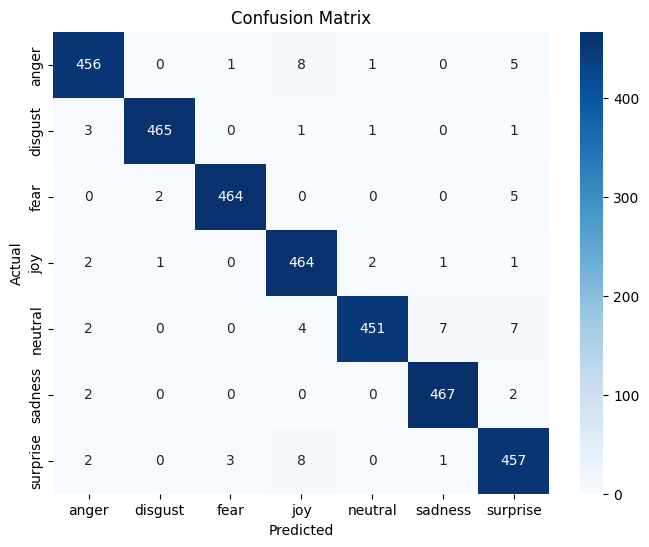

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# Confusion matrix: rows = actual, columns = predicted
# Diagonal = correct predictions; off-diagonal = misclassifications
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["anger","disgust","fear","joy","neutral","sadness","surprise"],
            yticklabels=["anger","disgust","fear","joy","neutral","sadness","surprise"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 5.5 Training Loss Curve

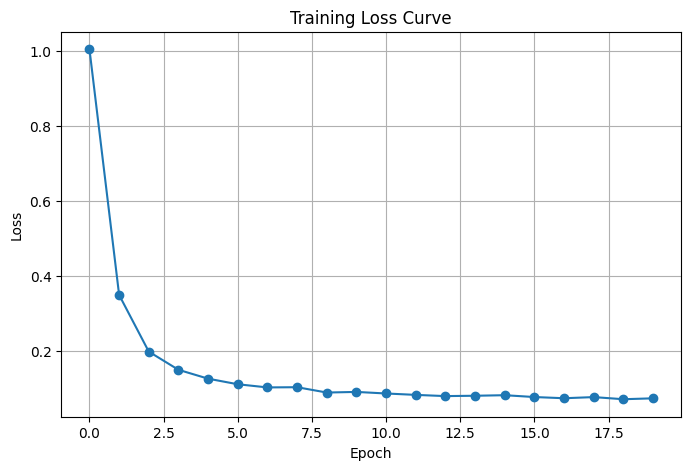

In [55]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(train_losses, marker='o')
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## 5.6 ROC Curve (Multi-class One-vs-Rest)

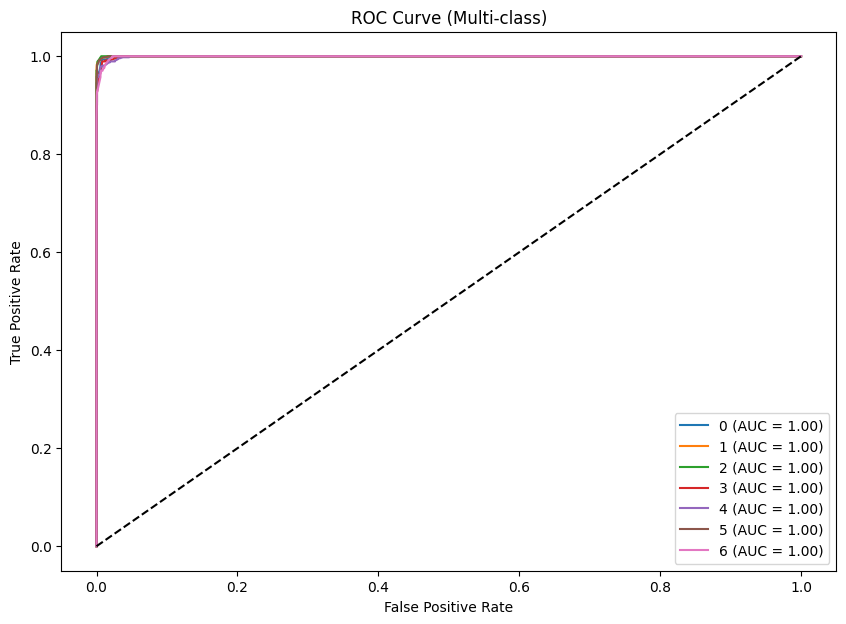

In [56]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Convert labels to one-hot
y_true = label_binarize(all_labels, classes=[0,1,2,3,4,5,6])
y_probs = np.array(all_probs)

n_classes = y_true.shape[1]

plt.figure(figsize=(10,7))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{i} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend()
plt.show()

## 5.7 Per-Class Accuracy Bar Chart

In [57]:
import pandas as pd
# Build a DataFrame of true vs predicted labels for easy groupby operations
df_results = pd.DataFrame({
    "true": all_labels,
    "pred": all_preds
})

class_accuracy = {}

# For each class, filter rows where true label == class, then compute accuracy
for cls in range(7):
    cls_df = df_results[df_results["true"] == cls]
    acc = (cls_df["true"] == cls_df["pred"]).mean()
    class_accuracy[cls] = acc

for k, v in class_accuracy.items():
    print(f"{k} ({id_to_emotion[k]}): {v:.2f}")

0 (anger): 0.97
1 (disgust): 0.99
2 (fear): 0.99
3 (joy): 0.99
4 (neutral): 0.96
5 (sadness): 0.99
6 (surprise): 0.97


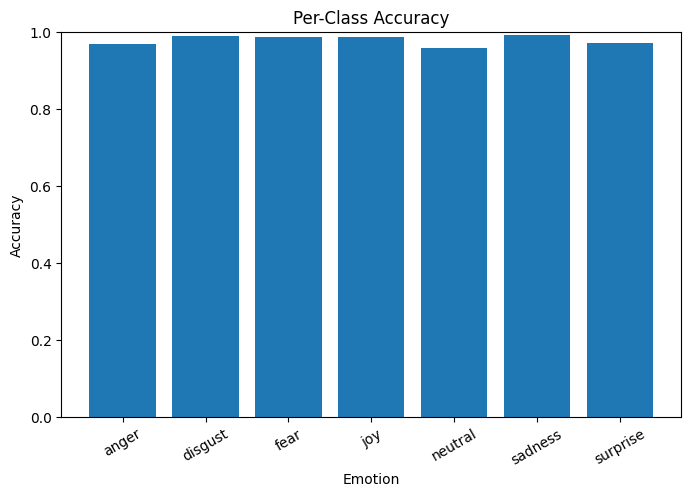

In [58]:
# Visualise per-class accuracy as a bar chart
labels = [id_to_emotion[i] for i in class_accuracy.keys()]
values = list(class_accuracy.values())

plt.figure(figsize=(8,5))
plt.bar(labels, values)

plt.title("Per-Class Accuracy")
plt.xlabel("Emotion")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)
plt.ylim(0,1)

plt.show()

---
# PART 6 — LOAD PRE-TRAINED TEXT MODEL (from Kaggle Dataset)
---
When resuming work or running inference-only, load a previously saved model
instead of retraining from scratch.

In [82]:
# Path to the saved model in the Kaggle input datasets section
model_path = "/kaggle/input/datasets/kirti1210/text-model"

In [83]:
from transformers import BertForSequenceClassification, BertTokenizer

# Load saved model weights and architecture from disk
model = BertForSequenceClassification.from_pretrained(model_path)
tokenizer = BertTokenizer.from_pretrained(model_path)

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.eval()# Set to inference mode immediately after loading

print("Model loaded successfully ")

Model loaded successfully 


In [84]:
# Inspect model architecture (layers, parameters)
print(model)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [85]:
# Re-define the reverse label mapping for inference output
id_to_emotion = {
    0: "anger",
    1: "disgust",
    2: "fear",
    3: "joy",
    4: "neutral",
    5: "sadness",
    6: "surprise"
}

In [86]:
def predict_text_emotion(text):
     """
    Classify a text string into one of 7 emotions and return a confidence score.
    Uses the pre-loaded BERT model and tokenizer.

    Returns:
        emotion    (str)  : Predicted emotion label.
        confidence (float): Probability of predicted class [0, 1].
    """
    model.eval()
    # Tokenise and move directly to device in one step
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=50
    ).to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()
    
    emotion = id_to_emotion[pred]
    confidence = probs[0][pred].item()
    
    return emotion, confidence

In [87]:
# Quick single-sentence test of the loaded model
text = "I am feeling really tired today"

emotion, conf = predict_text_emotion(text)

print(f"Text: {text}")
print(f"Emotion: {emotion}")
print(f"Confidence: {conf:.2f}")

Text: I am feeling really tired today
Emotion: neutral
Confidence: 0.98


---
# PART 7 — AUDIO MODEL: CNN ON MEL SPECTROGRAMS
---

We build a Convolutional Neural Network (CNN) to classify emotions from audio.

**Audio Feature Extraction Pipeline**:
```
MP4 Video File
  └─► Librosa (load audio, sr=16kHz)
        └─► Mel Spectrogram (128 bins)
              └─► Delta + Delta-Delta (velocity & acceleration)
                    └─► Stack to 3-channel 128×128 image
                          └─► CNN Input
```

The 3-channel image (Mel + Δ + Δ²) is analogous to RGB — giving the CNN
both spectral content AND temporal dynamics.

## 7.1 Explore Audio Files

In [2]:
import os

audio_path = "/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/train/train_splits"
print(os.listdir(audio_path)[:5])


['dia557_utt0.mp4', 'dia40_utt10.mp4', 'dia202_utt8.mp4', 'dia143_utt0.mp4', 'dia43_utt6.mp4']


In [3]:
# Install audio/video processing libraries
# moviepy → extract audio track from MP4 video files
# librosa → audio analysis, Mel spectrogram extraction
!pip install moviepy librosa


In [4]:
# Reload the training CSV for audio label construction
import pandas as pd

train_df = pd.read_csv("/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/train/train_sent_emo.csv")

In [5]:
# Quick inspection of dataset dimensions and column types
print(train_df.shape)
print(train_df.head())

(9989, 11)
   Sr No.                                          Utterance          Speaker  \
0       1  also I was the point person on my companys tr...         Chandler   
1       2                   You mustve had your hands full.  The Interviewer   
2       3                            That I did. That I did.         Chandler   
3       4      So lets talk a little bit about your duties.  The Interviewer   
4       5                             My duties?  All right.         Chandler   

    Emotion Sentiment  Dialogue_ID  Utterance_ID  Season  Episode  \
0   neutral   neutral            0             0       8       21   
1   neutral   neutral            0             1       8       21   
2   neutral   neutral            0             2       8       21   
3   neutral   neutral            0             3       8       21   
4  surprise  positive            0             4       8       21   

      StartTime       EndTime  
0  00:16:16,059  00:16:21,731  
1  00:16:21,940  00:16:

## 7.2 Build Filename → Label Lookup Table

In [7]:
from moviepy.editor import VideoFileClip
import librosa
import numpy as np
import os

# Pick one sample file
sample_file = os.path.join(audio_path, os.listdir(audio_path)[0])
print("Sample file:", sample_file)

# Load video
video = VideoFileClip(sample_file)

# Extract audio as numpy array
audio = video.audio.to_soundarray(fps=16000)

# Convert stereo to mono
audio = np.mean(audio, axis=1)

print("Audio shape:", audio.shape)


Sample file: /kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/train/train_splits/dia557_utt0.mp4
Audio shape: (46080,)


In [8]:
import librosa

sr = 16000  # same fps we used earlier

mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

print("MFCC shape:", mfcc.shape)


MFCC shape: (40, 91)


In [9]:
import numpy as np

mfcc_mean = np.mean(mfcc.T, axis=0)

print("Final feature vector shape:", mfcc_mean.shape)


Final feature vector shape: (40,)


In [10]:
label_lookup = {}# {filename: label_index}

for _, row in train_df.iterrows():

     # Reconstruct filename exactly as it appears in train_splits
    key = f"dia{row['Dialogue_ID']}_utt{row['Utterance_ID']}.mp4"
    
    label_lookup[key] = row['Emotion']   # ✅ FIXED

In [11]:
emotion_map = {
    "anger": 0,
    "disgust": 1,
    "fear": 2,
    "joy": 3,
    "neutral": 4,
    "sadness": 5,
    "surprise": 6
}

label_lookup = {
    k: emotion_map[v.lower()]
    for k, v in label_lookup.items()
}

In [12]:
import warnings
warnings.filterwarnings("ignore")  
import librosa
import numpy as np
import os
from tqdm import tqdm  

audio_features = []
audio_labels = []

files = os.listdir(audio_path)

for file in tqdm(files, desc="Processing Audio"):  
    
    if file in label_lookup:
        file_path = os.path.join(audio_path, file)
        
        try:
            # Load audio
            y, sr = librosa.load(file_path, sr=16000)
            
            # Extract MFCC
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
            mfcc_mean = np.mean(mfcc.T, axis=0)
            
            audio_features.append(mfcc_mean)
            audio_labels.append(label_lookup[file])
            
        except Exception as e:
            print("Error:", e)

print("Total processed samples:", len(audio_features))

Processing Audio:   7%|▋         | 696/9989 [02:22<29:32,  5.24it/s]

Error: 


Processing Audio: 100%|██████████| 9989/9989 [33:49<00:00,  4.92it/s]

Total processed samples: 9988


In [13]:
X = np.array(audio_features)
y = np.array(audio_labels)

print(X.shape, y.shape)

(9988, 40) (9988,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
from collections import Counter

counter = Counter(y)

print("Class distribution:")
for label, count in counter.items():
    print(f"Class {label}: {count}")

Class distribution:
Class 4: 4709
Class 3: 1743
Class 2: 268
Class 5: 683
Class 6: 1205
Class 0: 1109
Class 1: 271


In [17]:
X_aug = list(audio_features)
y_aug = list(audio_labels)

files = os.listdir(audio_path)

for file in tqdm(files, desc="Augmenting Data"):
    
    if file in label_lookup:
        
        label = label_lookup[file]
        
        # focus on minority classes
        if label in [1, 2, 5]:   # <-- your low classes
            
            file_path = os.path.join(audio_path, file)
            
            try:
                y, sr = librosa.load(file_path, sr=16000)
                
                # NOISE
                y_noise = add_noise(y)
                mfcc = librosa.feature.mfcc(y=y_noise, sr=sr, n_mfcc=40)
                X_aug.append(np.mean(mfcc.T, axis=0))
                y_aug.append(label)
                
                # TIME SHIFT
                y_shift = time_shift(y)
                mfcc = librosa.feature.mfcc(y=y_shift, sr=sr, n_mfcc=40)
                X_aug.append(np.mean(mfcc.T, axis=0))
                y_aug.append(label)
                
            except:
                continue

Augmenting Data: 100%|██████████| 9989/9989 [03:09<00:00, 52.63it/s] 


In [18]:
X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

In [19]:
import os
import pandas as pd
import numpy as np
import librosa
from tqdm import tqdm
import collections

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

2026-04-25 10:45:29.670428: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777113929.862691      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777113929.915854      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777113930.363943      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777113930.363974      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777113930.363977      55 computation_placer.cc:177] computation placer alr

#### LOAD AUDIO

In [20]:
train_df = pd.read_csv("/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/train/train_sent_emo.csv")

# remove missing values
train_df = train_df.dropna(subset=["Dialogue_ID", "Utterance_ID"])

print("Dataset loaded:", train_df.shape)

Dataset loaded: (9989, 11)


In [21]:
emotion_to_id = {
    "anger": 0,
    "disgust": 1,
    "fear": 2,
    "joy": 3,
    "neutral": 4,
    "sadness": 5,
    "surprise": 6
}

label_lookup = {}

for _, row in train_df.iterrows():
    dia = int(row["Dialogue_ID"])
    utt = int(row["Utterance_ID"])

     # Reconstruct filename exactly as it appears in train_splits
    key = f"dia{dia}_utt{utt}.mp4"
    
    label_lookup[key] = emotion_to_id[row["Emotion"]]

print("Labels created:", len(label_lookup))

Labels created: 9989


In [22]:
audio_path = "/kaggle/input/meld-dataset/MELD-RAW/MELD.Raw/train/train_splits"
# Cross-check: list all audio files available
files = os.listdir(audio_path)

print("Total audio files:", len(files))

Total audio files: 9989


In [23]:
# Sanity check: compare filename format between files and lookup keys
print("Files:", files[:5])
print("Labels:", list(label_lookup.keys())[:5])

Files: ['dia557_utt0.mp4', 'dia40_utt10.mp4', 'dia202_utt8.mp4', 'dia143_utt0.mp4', 'dia43_utt6.mp4']
Labels: ['dia0_utt0.mp4', 'dia0_utt1.mp4', 'dia0_utt2.mp4', 'dia0_utt3.mp4', 'dia0_utt4.mp4']


## 7.3 Mel Spectrogram Feature Extraction (3-Channel Image)

In [24]:
import numpy as np
import librosa

def augment_audio(y, sr):
"""
    Create augmented variants of an audio signal to improve model robustness.
    Returns a list of audio arrays: [original, noisy version].

    Augmentations:
      - Gaussian noise: simulates microphone noise / recording artifacts

    Note: Only 2 variants to balance augmentation benefit vs. memory usage.
    """
    #  Add noise
    noise = 0.005 * np.random.randn(len(y))# Small Gaussian noise
    y_noise = y + noise

    # KEEP ONLY 2 VERSIONS (memory safe)
    return [y, y_noise]

In [25]:
import cv2

def normalize_channel(x):
     """
    Min-max normalize a 2D array to the range [0, 1].
    The small epsilon (1e-6) prevents division by zero on silent audio.
    """
    x = x - x.min()
    return x / (x.max() + 1e-6)

def get_mel_image(y, sr):
"""
    Convert an audio signal into a 3-channel 128×128 image for CNN input.

    Channels:
      - Channel 0: Log-Mel Spectrogram   — captures spectral energy
      - Channel 1: Delta (Δ)             — captures first-order temporal change
      - Channel 2: Delta-Delta (Δ²)      — captures second-order temporal change

    Processing:
      1. Compute Mel spectrogram and convert to dB scale.
      2. Compute delta and delta-delta features.
      3. Normalise each channel to [0, 1].
      4. Resize all channels to 128×128 using OpenCV.
      5. Stack into a (128, 128, 3) float32 array.

    Args:
        y  (np.ndarray): Audio time series.
        sr (int)       : Sample rate (should be 16000 Hz).

    Returns:
        np.ndarray: Shape (128, 128, 3), dtype float32.
    """
 # Step 1: Mel spectrogram → decibel scale
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)

 # Step 2: Temporal derivatives
    delta = librosa.feature.delta(mel_db)
    delta2 = librosa.feature.delta(mel_db, order=2)

 # Step 3: Normalize each channel independently
    # normalize each channel
    mel_db = normalize_channel(mel_db)
    delta = normalize_channel(delta)
    delta2 = normalize_channel(delta2)

 # Step 4: Resize to fixed spatial dimensions for CNN
    mel_db = cv2.resize(mel_db, (128,128))
    delta = cv2.resize(delta, (128,128))
    delta2 = cv2.resize(delta2, (128,128))

# Step 5: Stack into (H, W, C) format — like an RGB image
    mel_stack = np.stack([mel_db, delta, delta2], axis=-1)

    return mel_stack.astype(np.float32)

In [26]:
X = np.array(audio_features)
y = np.array(audio_labels)

In [27]:
X = np.array(X)

In [28]:
print(X.shape)

(9988, 40)


## 7.4 Audio Augmentation Helpers

In [29]:
# Helper augmentation functions for minority class oversampling
def add_noise(y):
    
    """Add small Gaussian noise to simulate background noise."""
    return y + 0.005 * np.random.randn(len(y))

def time_shift(y):
    """Shift the audio signal by 10% of its length (circular shift).
    Simulates the utterance starting slightly earlier or later."""
    shift = int(0.1 * len(y))
    return np.roll(y, shift)

## 7.5 Load + Augment All Audio and Extract Features

In [30]:
# Strip .mp4 extension from label_lookup keys for flexible matching
label_lookup_fixed = {
    os.path.splitext(k)[0]: v   
    for k, v in label_lookup.items()
}

In [31]:
def load_audio(file_path):
    import librosa
    y, sr = librosa.load(file_path, sr=16000) # sr=16000 standard for speech models
    return y, sr

In [34]:
# Free previous arrays if they exist (avoid OOM in iterative runs)
del X
del y

In [35]:
# Main feature extraction loop
# For each audio file, load it, apply augmentation, extract Mel image features,
# and store features + labels
X = []# List of (128, 128, 3) feature arrays
y = [] # Corresponding integer labels

for file in tqdm(sorted(files)): # tqdm shows a progress bar

    if file in label_lookup: # Only process files that have a label

        file_path = os.path.join(audio_path, file)
        label = label_lookup[file]

        try:
            y_audio, sr = load_audio(file_path)

            # Generate augmented variants: [original, noisy]
            augmented = augment_audio(y_audio, sr)

            for y_aug in augmented:
                feature = get_mel_image(y_aug, sr)

                X.append(feature)
                y.append(label)

        except:
            continue
# Convert to numpy arrays; float16 halves memory usage vs float32
X = np.array(X, dtype=np.float16)   # also reduce memory
y = np.array(y)

100%|██████████| 9989/9989 [33:58<00:00,  4.90it/s]


## 7.6 Visualise Extracted Features

In [36]:
# Sanity check: confirm value range is [0, 1] after normalisation
print("Min:", X.min(), "Max:", X.max())
print("Sample feature:", X[0])

Min: 0.0 Max: 1.0
Sample feature: [[[0.547   0.5537  0.4663 ]
  [0.5845  0.5537  0.4663 ]
  [0.631   0.5537  0.4663 ]
  ...
  [0.4294  0.4358  0.501  ]
  [0.385   0.4358  0.501  ]
  [0.4023  0.4358  0.501  ]]

 [[0.7817  0.4595  0.4778 ]
  [0.8213  0.4595  0.4778 ]
  [0.8135  0.4595  0.4778 ]
  ...
  [0.509   0.4377  0.4983 ]
  [0.5073  0.4377  0.4983 ]
  [0.5215  0.4377  0.4983 ]]

 [[0.862   0.456   0.4805 ]
  [0.891   0.456   0.4805 ]
  [0.8887  0.456   0.4805 ]
  ...
  [0.4783  0.348   0.5913 ]
  [0.515   0.348   0.5913 ]
  [0.5244  0.348   0.5913 ]]

 ...

 [[0.447   0.5127  0.505  ]
  [0.4797  0.5127  0.505  ]
  [0.5073  0.5127  0.505  ]
  ...
  [0.3723  0.523   0.3406 ]
  [0.2715  0.523   0.3406 ]
  [0.2688  0.523   0.3406 ]]

 [[0.4612  0.5103  0.5776 ]
  [0.4524  0.5103  0.5776 ]
  [0.4126  0.5103  0.5776 ]
  ...
  [0.3088  0.521   0.3499 ]
  [0.2272  0.521   0.3499 ]
  [0.2106  0.521   0.3499 ]]

 [[0.3247  0.499   0.5664 ]
  [0.3477  0.499   0.5664 ]
  [0.2512  0.499   0.566

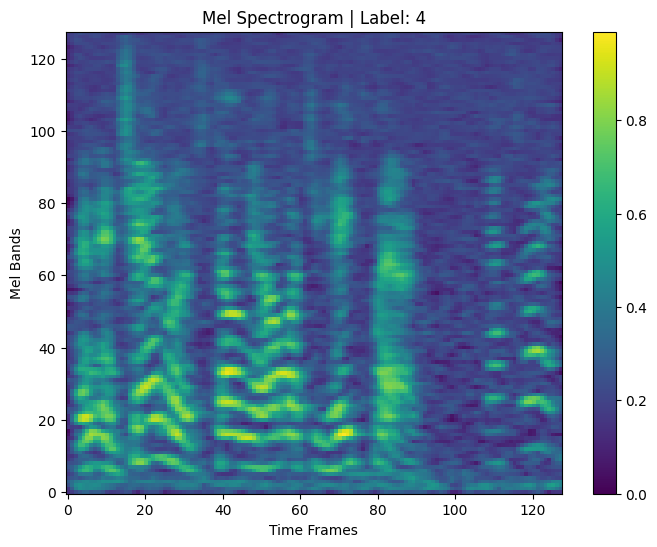

In [38]:
import matplotlib.pyplot as plt

# Visualise Channel 0 (Mel spectrogram) for the first sample
# Brighter colours = higher energy at that frequency-time point
# choose sample index
idx = 0

plt.figure(figsize=(8,6))

# channel 0 = Mel spectrogram
plt.imshow(X[idx][:, :, 0], aspect='auto', origin='lower', cmap='viridis')

plt.colorbar()
plt.title(f"Mel Spectrogram | Label: {y[idx]}")
plt.xlabel("Time Frames")
plt.ylabel("Mel Bands")

plt.show()

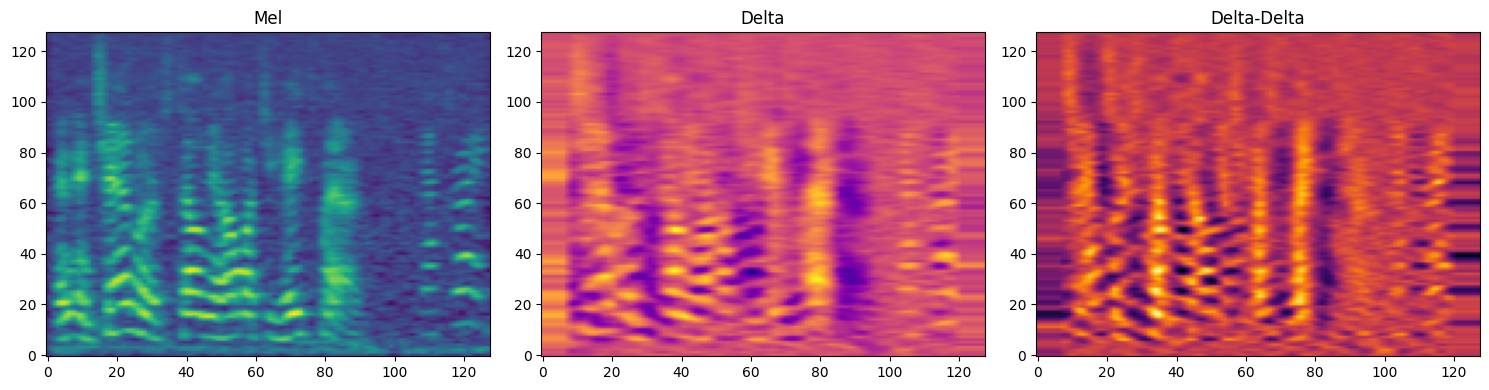

In [39]:
# Side-by-side view of all 3 channels for one sample
# Mel: spectral shape; Delta: change in spectrum; Delta-Delta: rate of change
fig, ax = plt.subplots(1, 3, figsize=(15,4))

ax[0].imshow(X[0][:,:,0], aspect='auto', origin='lower', cmap='viridis')
ax[0].set_title("Mel")

ax[1].imshow(X[0][:,:,1], aspect='auto', origin='lower', cmap='plasma')
ax[1].set_title("Delta")

ax[2].imshow(X[0][:,:,2], aspect='auto', origin='lower', cmap='inferno')
ax[2].set_title("Delta-Delta")

plt.tight_layout()
plt.show()

## 7.7 Train-Test Split for Audio Model

In [40]:
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

# Shuffle before splitting to ensure class mixing
X, y = shuffle(X, y, random_state=42)

# 75% training / 25% test; stratify preserves class ratios in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

In [41]:
import numpy as np

In [42]:
X = np.array(X)
y = np.array(y)

In [43]:
print("Min:", X.min())
print("Max:", X.max())
print("Mean:", X.mean())

print(X[0][:,:,0].mean(), X[0][:,:,1].mean(), X[0][:,:,2].mean())

Min: 0.0
Max: 1.0
Mean: 0.472
0.3042 0.4873 0.4998


In [44]:
X = np.array(X)
print(X.shape)

(19716, 128, 128, 3)


In [45]:
print(X[0].shape)

(128, 128, 3)


In [46]:
from collections import Counter

print(Counter(y))

Counter({np.int64(4): 9294, np.int64(3): 3426, np.int64(6): 2378, np.int64(0): 2186, np.int64(5): 1360, np.int64(1): 542, np.int64(2): 530})


In [47]:
counter = collections.Counter(label_lookup_fixed.values())

max_count = max(counter.values())

minority_classes = [
    label for label, count in counter.items()
    if count < 0.6 * max_count
]

print("Minority classes:", minority_classes)

Minority classes: [6, 2, 5, 3, 1, 0]


In [48]:
print (X.shape)

(19716, 128, 128, 3)


In [49]:
print(X.shape)
print(X[0].shape)

(19716, 128, 128, 3)
(128, 128, 3)


In [50]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

#### TRAIN-TEST SPLIT

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

## 7.8 Compute Class Weights for Imbalanced Audio Data

In [52]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)   # use y_train (NOT y_new)

# compute_class_weight('balanced') automatically calculates weights as:
# weight[c] = total_samples / (n_classes * count[c])
# → minority classes get HIGHER weight → model penalised more for misclassifying them
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

# ensure keys are normal int (important)
class_weights_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}

print(class_weights_dict)

{0: 1.2880662020905924, 1: 5.1902421902421905, 2: 5.320978769341489, 3: 0.8222765945615303, 4: 0.3030744004919041, 5: 2.0710084033613447, 6: 1.184096732863549}


## 7.9 Build the CNN Model

In [53]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import BatchNormalization

In [55]:
import tensorflow as tf
from tensorflow.keras import layers

# CNN Architecture — 3 convolutional blocks followed by fully connected layers
#
# Each block: Conv2D → BatchNorm → MaxPool
#   Conv2D      : learns local spatial features (edges, textures in spectrogram)
#   BatchNorm   : normalises activations → faster training, more stable gradients
#   MaxPooling  : downsamples spatial dimensions → reduces parameters, adds invariance
#
# Head: Flatten → Dense(256) → Dropout(0.4) → Dense(128) → Dropout(0.3) → Softmax(7)
#   Dropout     : randomly zeros neurons during training → prevents over-fitting
#   Softmax     : converts final logits to class probabilities

model = tf.keras.Sequential([
    layers.Input(shape=(128,128,3)), # (H, W, Channels) — Mel + Δ + Δ²
    
    # Block 1: 32 filters — learns low-level features (edges, onset bursts)
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

     # Block 2: 64 filters — learns mid-level patterns (phoneme-like structures)
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Block 3: 128 filters — learns high-level emotion-specific features
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Flatten spatial features into a 1D vector
    layers.Flatten(),

    # Fully connected layers for final classification
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),# 40% dropout for strong regularisation

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), # 30% dropout in later layer

     # Output layer: one logit per emotion class → softmax for probabilities
    layers.Dense(len(np.unique(y)), activation='softmax')
])

In [56]:
# Compile with Adam (adaptive learning rate) and sparse categorical cross-entropy
# sparse_categorical_crossentropy: labels are integers (not one-hot) — more memory efficient
# lr=1e-4: slower learning rate than BERT — CNN converges more smoothly at lower LRmodel.compile()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [57]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Learning rate scheduler: reduces LR when validation loss plateaus
# factor=0.3 → multiply LR by 0.3 (aggressive reduction)
# patience=3 → wait 3 epochs of no improvement before reducing
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    verbose=1
)

In [58]:
# Train the CNN model
# class_weight=class_weights_dict applies higher loss penalty to minority classes
# This is the primary mechanism for handling audio class imbalance
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[lr_scheduler]
)

Epoch 1/50


I0000 00:00:1777118720.559910  312105 service.cc:152] XLA service 0x7f6cf4012210 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777118720.559961  312105 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777118721.125116  312105 cuda_dnn.cc:529] Loaded cuDNN version 91002


 13/463 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.1581 - loss: 3.6465

I0000 00:00:1777118725.567309  312105 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


463/463 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.1431 - loss: 2.4976 - val_accuracy: 0.1850 - val_loss: 1.9115 - learning_rate: 1.0000e-04
Epoch 2/50
463/463 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.0912 - loss: 1.9677 - val_accuracy: 0.1720 - val_loss: 1.9195 - learning_rate: 1.0000e-04
Epoch 3/50
463/463 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.0756 - loss: 1.9462 - val_accuracy: 0.1509 - val_loss: 1.9295 - learning_rate: 1.0000e-04
Epoch 4/50
461/463 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1101 - loss: 1.9377
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
463/463 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.1101 - loss: 1.9376 - val_accuracy: 0.1160 - val_loss: 1.9586 - learning_rate: 1.0000e-04
Epoch 5/50
463/463 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.1380 - loss: 1.9040 - val_accuracy: 0.1445 - val_loss: 1.9267 - learning_rate: 3.0000e-05
Epoch 6/50
463/463 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.1521 

In [60]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Quick confusion matrix after training to see which classes the model confuses
y_pred = np.argmax(model.predict(X_test), axis=1)
print(confusion_matrix(y_test, y_pred))

155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
[[ 220    3    7  113  145   16   42]
 [  12   47    0   23   33   10   10]
 [   4    1   50   13   44    9   12]
 [  70    3    4  332  318   47   83]
 [ 154   11   19  395 1345  144  256]
 [  19    5    2   41  122  127   24]
 [  35    0    5   99  213   26  216]]


## 7.10 Save & Load Audio Model

In [61]:
# Save model in Keras native format (.keras)
# Preserves architecture, weights, optimizer state, and training config
model.save("/kaggle/working/audio_emotion_model.keras")

In [62]:
# Load a previously saved audio model from Kaggle dataset
from tensorflow.keras.models import load_model

model = load_model("/kaggle/input/models/kirti1210/audio-model/keras/default/1/audio_emotion_model.keras")

print("Audio model loaded successfully ")

Audio model loaded successfully 


## 7.11 Audio Model Evaluation

In [63]:
# Evaluate model on test set
loss, acc = model.evaluate(X_test, y_test, verbose=1)

print("Test Loss:", loss)
print("Test Accuracy:", acc)

155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8658 - loss: 0.4816
Test Loss: 0.48672959208488464
Test Accuracy: 0.8614323139190674


In [66]:
import numpy as np

# Predict first 5 samples
# Compare predictions vs ground truth for the first 10 test samples
pred_probs = model.predict(X_test[:10])
pred_labels = np.argmax(pred_probs, axis=1)

print("Predicted Labels:", pred_labels)
print("Actual Labels   :", y_test[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step
Predicted Labels: [4 6 4 4 3 3 4 4 0 5]
Actual Labels   : [6 6 3 4 3 3 4 4 0 3]


In [65]:
from sklearn.metrics import classification_report

# Full classification report: precision, recall, F1 per class + macro/weighted averages
y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_pred))

155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
              precision    recall  f1-score   support

           0       0.90      0.79      0.84       546
           1       1.00      0.85      0.92       135
           2       0.94      0.85      0.89       133
           3       0.87      0.80      0.83       857
           4       0.84      0.93      0.88      2324
           5       0.89      0.79      0.83       340
           6       0.86      0.81      0.83       594

    accuracy                           0.86      4929
   macro avg       0.90      0.83      0.86      4929
weighted avg       0.86      0.86      0.86      4929



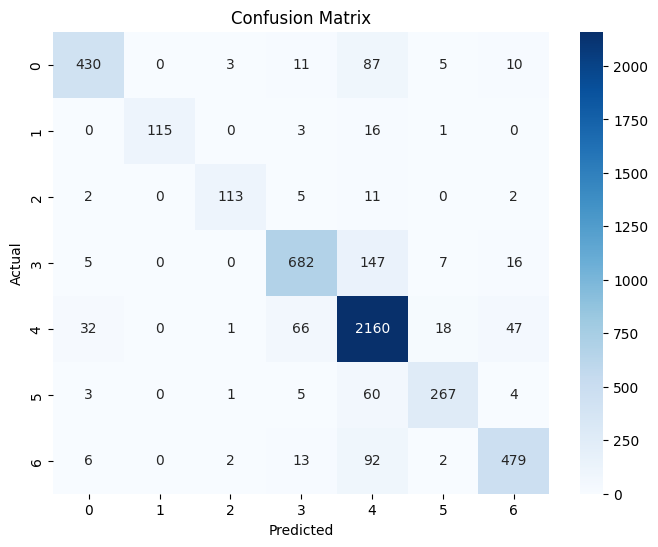

In [67]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Audio confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

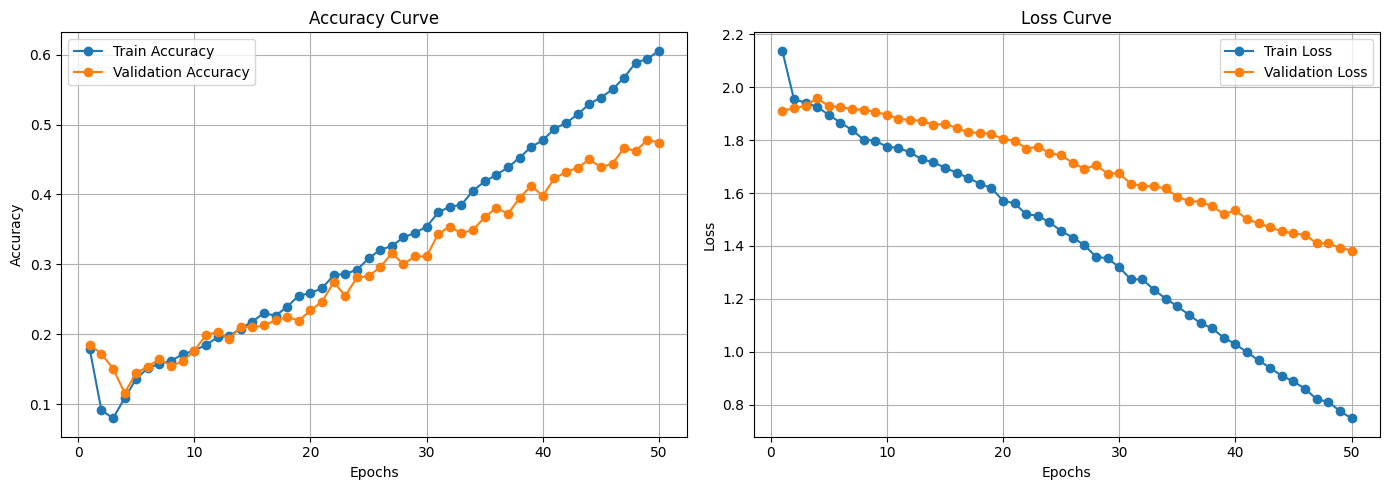

In [68]:
import matplotlib.pyplot as plt

# Training history curves — monitor for over-fitting
# Over-fitting symptom: train accuracy rises while val accuracy plateaus/falls
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(train_acc) + 1)

plt.figure(figsize=(14,5))

# Accuracy Curve
plt.subplot(1,2,1)
plt.plot(epochs_range, train_acc, label='Train Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Curve
plt.subplot(1,2,2)
plt.plot(epochs_range, train_loss, label='Train Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [70]:
import os
import librosa
import numpy as np
import pandas as pd

# Folder containing unseen audio files for testing
test_folder = "/kaggle/input/datasets/kirti1210/audio-testing"

# Integer → emotion string mapping for readable output
label_map = {
    0: "anger",
    1: "disgust",
    2: "fear",
    3: "joy",
    4: "neutral",
    5: "sadness",
    6: "surprise"
}

results = []

for file in os.listdir(test_folder):

  
  # Support common audio formats (aac often used in phones)
    if file.lower().endswith((".wav", ".mp3", ".flac", ".aac")):

        file_path = os.path.join(test_folder, file)

        try:
            # load audio
            y, sr = librosa.load(file_path, sr=16000)

            # feature extraction
            feature = get_mel_image(y, sr)
            X_new = np.expand_dims(feature, axis=0)

            # prediction
            pred = model.predict(X_new, verbose=0)
            pred_class = np.argmax(pred, axis=1)[0]
            pred_label = label_map[pred_class]
            confidence = float(np.max(pred))

            results.append([file, pred_label, round(confidence, 4)])

        except Exception as e:
            print(f"Error in {file}: {e}")

df = pd.DataFrame(results, columns=["File Name", "Predicted Emotion", "Confidence"])
print(df)

       File Name Predicted Emotion  Confidence
0  sarcasm_5.aac           neutral      0.8447
1  sarcasm_4.aac           neutral      0.6587
2  sarcasm_2.aac           neutral      0.7938
3  sarcasm_3.aac           neutral      0.7344
4  sarcasm_6.aac           neutral      0.8260
5  sarcasm_1.aac           neutral      0.3701


---
# PART 8 — MULTIMODAL SARCASM DETECTION
---
Sarcasm often manifests as a **mismatch between what is said (text) and how it is said (voice)**.
For example, saying *"Oh great, another Monday"* with a sad or angry tone is sarcastic —
the positive word *"great"* conflicts with the negative vocal affect.

**Detection Logic**:
```
if text_emotion != audio_emotion:
    → Sarcasm likely (mismatch detected)
else:
    → No sarcasm (both channels agree)
```

In [72]:
# Audio emotion to sentiment mapping
audio_to_sentiment = {
    0: "Negative",   # anger
    1: "Negative",   # disgust
    2: "Negative",   # fear
    3: "Positive",   # joy
    4: "Neutral",    # neutral
    5: "Negative",   # sadness
    6: "Positive"    # surprise
}

print("Mapping ready ")

Mapping ready 


#### Create Text Sentiment Prediction Function

In [74]:
def predict_text_sentiment(text):
    
    # Convert text using vectorizer
    text_vec = vectorizer.transform([text])
    
    # Predict probabilities
    probs = text_model.predict_proba(text_vec)[0]
    
    labels = text_model.classes_
    
    result = dict(zip(labels, probs))
    
    final_label = labels[probs.argmax()]
    
    return result, final_label

print("Text Sentiment Prediction Completed.")

Text Sentiment Prediction Completed.


## 8.2 Audio Sentiment Prediction Function

In [124]:
from tensorflow.keras.models import load_model

# Load saved CNN audio model
audio_model = load_model(
    "/kaggle/input/models/kirti1210/audio-model/keras/default/1/audio_emotion_model.keras"
)

print("Audio model loaded ")

Audio model loaded 


In [125]:
def predict_audio_sentiment(audio_path):
 """
    Predict the sentiment polarity (Positive/Negative/Neutral) of an audio file.

    Steps:
      1. Load audio at 16kHz.
      2. Extract 3-channel Mel image feature.
      3. Predict emotion class probabilities with CNN.
      4. Map predicted emotion → sentiment polarity.

    Args:
        audio_path (str): Path to audio/video file.

    Returns:
        tuple: (sentiment: str, confidence: float)
    """
    
    y, sr = librosa.load(audio_path, sr=16000)

    feature = get_mel_image(y, sr)# Feature extraction
    X_new = np.expand_dims(feature, axis=0)# (1, 128, 128, 3) batch

    probs = audio_model.predict(X_new, verbose=0)[0] # (7,) probability vector

    pred_class = np.argmax(probs) # Best emotion index

    sentiment = audio_to_sentiment[pred_class]
    confidence = float(np.max(probs))

    return sentiment, confidence

## 8.3 Speech-to-Text with OpenAI Whisper

In [77]:
# Install Whisper and its system dependency (ffmpeg for audio decoding)
!pip install -q openai-whisper
!sudo apt update && sudo apt install ffmpeg -y

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 21.1 MB/s eta 0:00:0000:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Get:7 https://cli.github.com/packages stable/main amd64 Packages [357 B]       
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,546 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]           
Get:10 http://archive

In [78]:
import whisper

# Load 'base' Whisper model — small and fast, good for short utterances
# Other options: 'tiny' (fastest), 'small', 'medium', 'large' (most accurate)
whisper_model = whisper.load_model("base")

def transcribe_audio(audio_path):
    """
    Convert speech audio to text using OpenAI's Whisper model.

    Whisper is an end-to-end ASR model trained on 680k hours of speech.
    It handles multiple languages, accents, and background noise well.

    Args:
        audio_path (str): Path to audio/video file.

    Returns:
        str: Transcribed text.
    """
    result = whisper_model.transcribe(audio_path)
    
    return result["text"]

print("Speech-to-Text (Audio Transcript) done")

100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 189MiB/s]


Speech-to-Text (Audio Transcript) done


In [79]:
def transcribe_audio(audio_path):
    result = whisper_model.transcribe(audio_path)
    return result["text"]

## 8.4 Sarcasm Detection Logic

In [80]:
def detect_sarcasm(text_sentiment, audio_sentiment, text_conf, audio_conf):
    """
    Determine whether sarcasm is present based on text-audio sentiment mismatch.

    Logic:
      - If text and audio sentiments DIFFER → likely sarcasm
        Score = average of both confidences × 100  (higher confidence = more likely sarcasm)
      - If text and audio sentiments AGREE  → no sarcasm
        Score = low value based on confidence gap  (close confidences = strong agreement)

    Args:
        text_sentiment  (str)  : Text emotion polarity.
        audio_sentiment (str)  : Audio emotion polarity.
        text_conf       (float): Confidence from text model [0, 1].
        audio_conf      (float): Confidence from audio model [0, 1].

    Returns:
        tuple: (sarcasm: 'Yes'/'No', sarcasm_score: float)
    """
    if text_sentiment != audio_sentiment:
        sarcasm = "Yes"
        sarcasm_score = round((text_conf + audio_conf) / 2 * 100, 2)
    else:
        sarcasm = "No"
        sarcasm_score = round((1 - abs(text_conf - audio_conf)) * 20, 2)
    
    return sarcasm, sarcasm_score

print("Sarcasm detection Logic done ")

Sarcasm detection Logic done 


## 8.5 Single File Pipeline Test

In [126]:
text = "I am feeling really alone today"

emotion, conf = predict_text_emotion(text)

print(f"Text: {text}")
print(f"Emotion: {emotion}")
print(f"Confidence: {conf:.2f}")

Text: I am feeling really alone today
Emotion: sadness
Confidence: 0.94


In [139]:
import os
import random

# Pick a random audio file from the test folder
dataset_path = "/kaggle/input/datasets/kirti1210/audio-testing"

# Collect audio files
files = [
    os.path.join(dataset_path, f)
    for f in os.listdir(dataset_path)
    if f.lower().endswith((".wav", ".mp3", ".flac", ".aac"))
]

print("Total audio files found:", len(files))

# Pick random file
sample_file = random.choice(files)
print("Selected File:", sample_file)

Total audio files found: 6
Selected File: /kaggle/input/datasets/kirti1210/audio-testing/sarcasm_3.aac


In [140]:
# Step 1: Transcribe audio to text using Whisper
transcript = transcribe_audio(sample_file)

# Step 2: Predict text emotion from transcript using BERT
text_label, text_conf = predict_text_emotion(transcript)

print("Transcript:", transcript)
print("Text Sentiment:", text_label)
print("Confidence:", text_conf)

Transcript:  Yeah, I'm so excited for this.
Text Sentiment: joy
Confidence: 0.9954546689987183


In [141]:
# Step 3: Predict audio sentiment directly from the raw audio using CNN
audio_label, audio_conf = predict_audio_sentiment(sample_file)

print("Audio Sentiment:", audio_label)
print("Confidence:", audio_conf)

Audio Sentiment: Neutral
Confidence: 0.7343800663948059


In [142]:
# Step 4: Compare text and audio sentiment → detect sarcasm
text_label, text_conf = predict_text_emotion(transcript)

# Get audio prediction
audio_label, audio_conf = predict_audio_sentiment(sample_file)

# Compare both
if text_label.lower() != audio_label.lower():
    sarcasm = "Yes 😏" # Mismatch = likely sarcasm
    sarcasm_score = round(((text_conf + audio_conf) / 2) * 100, 2)
else:
    sarcasm = "No 🙂" # Agreement = no sarcasm
    sarcasm_score = round((1 - abs(text_conf - audio_conf)) * 20, 2)

# Step 5: Print full prediction summary
print("🎵 File Name       :", sample_file.split("/")[-1])
print("📝 Transcript      :", transcript)

print("📊 Text Sentiment  :", text_label, "|", round(text_conf, 2))
print("🎤 Audio Sentiment :", audio_label, "|", round(audio_conf, 2))

print("😏 Sarcasm         :", sarcasm)
print("🔥 Sarcasm Score   :", sarcasm_score, "%")

🎵 File Name       : sarcasm_3.aac
📝 Transcript      :  Yeah, I'm so excited for this.
📊 Text Sentiment  : joy | 1.0
🎤 Audio Sentiment : Neutral | 0.73
😏 Sarcasm         : Yes 😏
🔥 Sarcasm Score   : 86.49 %


## 8.6 Batch Inference on All Test Audio Files

In [143]:
import os
import pandas as pd

# Folder path
dataset_path = "/kaggle/input/datasets/kirti1210/audio-testing"

# Get all audio files
files = [
    os.path.join(dataset_path, f)
    for f in os.listdir(dataset_path)
    if f.lower().endswith((".wav", ".mp3", ".flac", ".aac"))
]

results = []

for sample_file in files:
    try:
        # 1. Speech-to-text
        transcript = transcribe_audio(sample_file)

        # 2. Text sentiment
        text_label, text_conf = predict_text_emotion(transcript)

        # 3. Audio sentiment
        audio_label, audio_conf = predict_audio_sentiment(sample_file)

       # 4. Sarcasm detection: mismatch → sarcasm; agreement → no sarcasm
        if text_label.lower() != audio_label.lower():
            sarcasm = "Yes"
            sarcasm_score = round(((text_conf + audio_conf) / 2) * 100, 2)
        else:
            sarcasm = "No"
            sarcasm_score = round((1 - abs(text_conf - audio_conf)) * 20, 2)

        # 5. Save result
        results.append({
            "File Name": os.path.basename(sample_file),
            "Transcript": transcript,
            "Text Sentiment": text_label,
            "Text Confidence": round(float(text_conf), 4),
            "Audio Sentiment": audio_label,
            "Audio Confidence": round(float(audio_conf), 4),
            "Sarcasm": sarcasm,
            "Sarcasm Score (%)": sarcasm_score
        })

    except Exception as e:
        # Record error rows instead of crashing the loop
        results.append({
            "File Name": os.path.basename(sample_file),
            "Transcript": "Error",
            "Text Sentiment": "-",
            "Text Confidence": "-",
            "Audio Sentiment": "-",
            "Audio Confidence": "-",
            "Sarcasm": f"Error: {str(e)}",
            "Sarcasm Score (%)": "-"
        })

# Compile results into a DataFrame
df_results = pd.DataFrame(results)

# Show table
print(df_results)

# Save to CSV for external review
df_results.to_csv("sarcasm_test_results.csv", index=False)
print("Results saved as sarcasm_test_results.csv ✅")

       File Name                         Transcript Text Sentiment  \
0  sarcasm_5.aac        Wow, that was just amazing.            joy   
1  sarcasm_4.aac   Thanks a lot that really helped.            joy   
2  sarcasm_2.aac           It's fine, I don't care.        neutral   
3  sarcasm_3.aac     Yeah, I'm so excited for this.            joy   
4  sarcasm_6.aac      Oh great, another assignment.            joy   
5  sarcasm_1.aac          I'm very happy right now.        neutral   

   Text Confidence Audio Sentiment  Audio Confidence Sarcasm  \
0           0.9989         Neutral            0.8447     Yes   
1           0.9950         Neutral            0.6587     Yes   
2           0.9991         Neutral            0.7938      No   
3           0.9955         Neutral            0.7344     Yes   
4           0.8866         Neutral            0.8260     Yes   
5           0.9975         Neutral            0.3701      No   

   Sarcasm Score (%)  
0              92.18  
1             

---
# PART 9 — STREAMLIT WEB APPLICATION
---
A simple interactive demo that allows users to upload an audio file and receive
real-time sarcasm detection results through a web UI.

In [145]:
# Install Streamlit web framework
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 73.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 112.1 MB/s eta 0:00:0000:010:01


In [147]:
import streamlit as st

# Streamlit app for real-time sarcasm detection
# Users upload an audio file → full pipeline runs → results displayed
st.title("Real-Time Sarcasm Detection")

# File uploader widget — accepts WAV, MP3, AAC
audio_file = st.file_uploader(
    "Upload Audio",
    type=["wav", "mp3", "aac"]
)

if audio_file is not None:

     # Save uploaded file as a temporary file on disk for processing
    with open("temp_audio.wav", "wb") as f:
        f.write(audio_file.read())

    # Display audio player in the browser
    st.audio(audio_file)

   # Run the full multimodal pipeline
    transcript = transcribe_audio("temp_audio.wav") # Whisper STT
    text_label, text_conf = predict_text_emotion(transcript) # BERT text model
    audio_label, audio_conf = predict_audio_sentiment("temp_audio.wav") # CNN audio

    # Sarcasm detection: sentiment mismatch = sarcasm
    if text_label.lower() != audio_label.lower():
        sarcasm = "Yes 😏"
    else:
        sarcasm = "No 🙂"

    # Display results in the Streamlit UI
    st.write("Transcript:", transcript)
    st.write("Text Sentiment:", text_label)
    st.write("Audio Sentiment:", audio_label)
    st.success("Sarcasm: " + sarcasm)

2026-04-25 13:05:39.554 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 13:05:39.556 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 13:05:39.556 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 13:05:39.557 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 13:05:39.558 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 13:05:39.559 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 13:05:39.560 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 13:05:39.560 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [148]:
import streamlit as st

st.title("Real-Time Sarcasm Detection")

audio_file = st.file_uploader(
    "Upload Audio",
    type=["wav", "mp3", "aac"]
)

if audio_file is not None:

    # Save temporary file
    with open("temp_audio.wav", "wb") as f:
        f.write(audio_file.read())

    st.audio(audio_file)

    # Run pipeline
    transcript = transcribe_audio("temp_audio.wav")
    text_label, text_conf = predict_text_emotion(transcript)
    audio_label, audio_conf = predict_audio_sentiment("temp_audio.wav")

    if text_label.lower() != audio_label.lower():
        sarcasm = "Yes 😏"
    else:
        sarcasm = "No 🙂"

    st.write("Transcript:", transcript)
    st.write("Text Sentiment:", text_label)
    st.write("Audio Sentiment:", audio_label)
    st.success("Sarcasm: " + sarcasm)

2026-04-25 13:06:00.460 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 13:06:00.462 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 13:06:00.463 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 13:06:00.463 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 13:06:00.464 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 13:06:00.465 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 13:06:00.465 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 13:06:00.467 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar